In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
columnns = ['pipe_size','thickness','mat','grade','max_press','temp','corr_per','thickness_loss','mat_percent','time_years','condition']

In [3]:
pipedata1 = pd.read_csv('pipedata.csv', names = columnns)

In [4]:
df = pipedata1.drop(0)

In [5]:
data = df[['pipe_size','thickness','max_press','temp','corr_per','thickness_loss','mat_percent','time_years','condition']]

In [6]:
data['condition'].unique()

array(['Moderate', 'Critical', 'Normal'], dtype=object)

In [7]:
data.loc[data['condition'] == 'Normal','condition'] = 0
data.loc[data['condition'] == 'Moderate','condition'] = 1
data.loc[data['condition'] == 'Critical','condition'] = 2


C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\560508593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data['condition'] == 'Normal','condition'] = 0
C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\560508593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[data['condition'] == 'Moderate','condition'] = 1
C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\560508593.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

In [8]:
data['condition'] = data['condition'].astype(int)

C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\2934528239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['condition'] = data['condition'].astype(int)


In [9]:
data[data.columns[0:]] = data[data.columns[0:]].astype(float)

C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\292952893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[data.columns[0:]] = data[data.columns[0:]].astype(float)


In [10]:
data['condition'] = data['condition'].astype(int)

C:\Users\Derah\AppData\Local\Temp\ipykernel_11600\2934528239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['condition'] = data['condition'].astype(int)


In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 1 to 1000
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   pipe_size       1000 non-null   float64
 1   thickness       1000 non-null   float64
 2   max_press       1000 non-null   float64
 3   temp            1000 non-null   float64
 4   corr_per        1000 non-null   float64
 5   thickness_loss  1000 non-null   float64
 6   mat_percent     1000 non-null   float64
 7   time_years      1000 non-null   float64
 8   condition       1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [12]:
columns = ['pipe_size','thickness','max_press','temp','corr_per','thickness_loss','mat_percent','time_years','conditions']

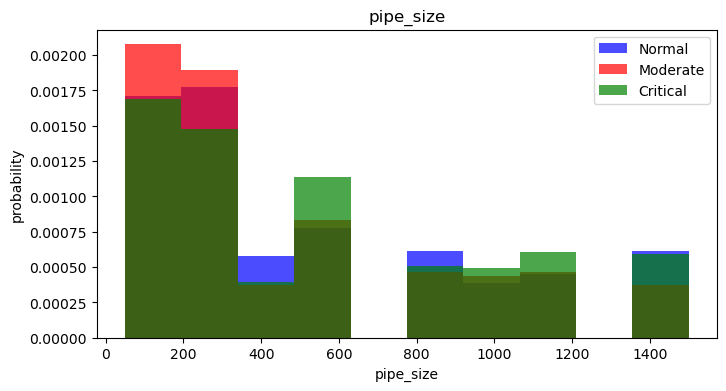

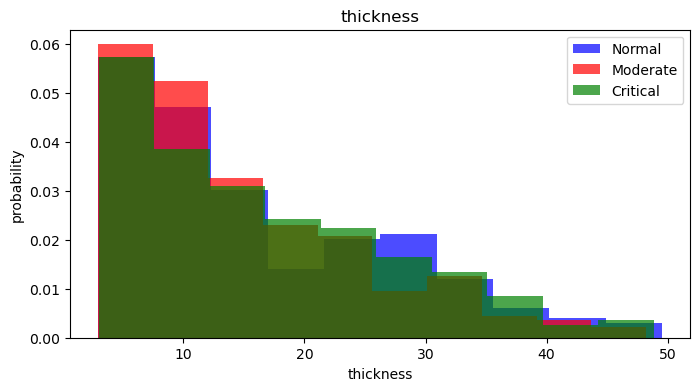

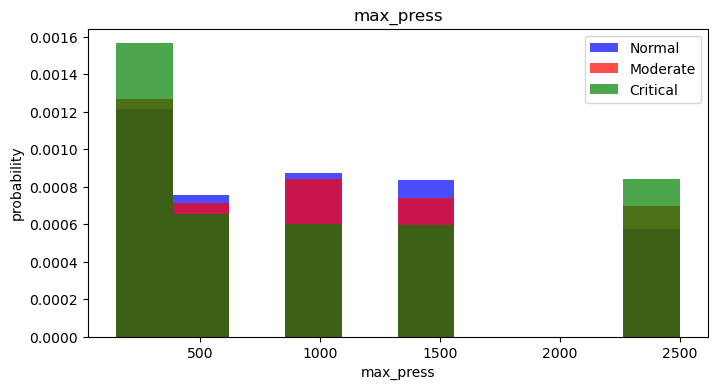

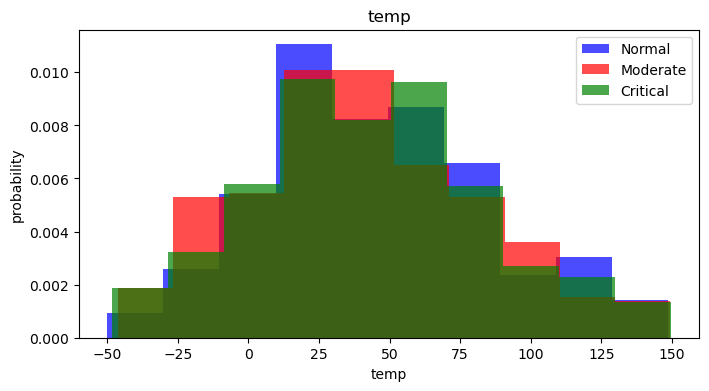

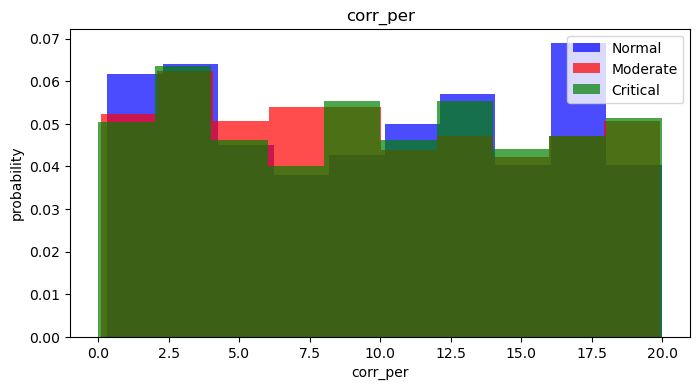

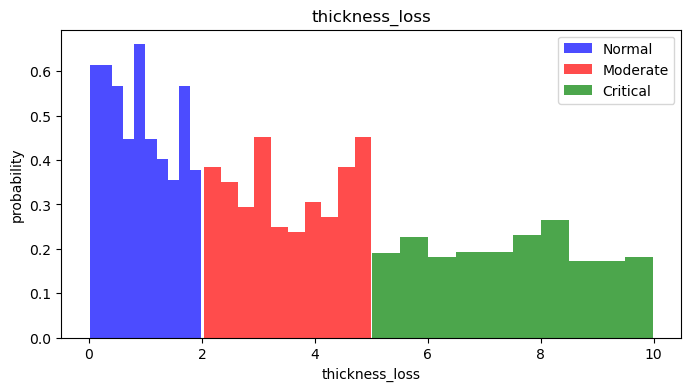

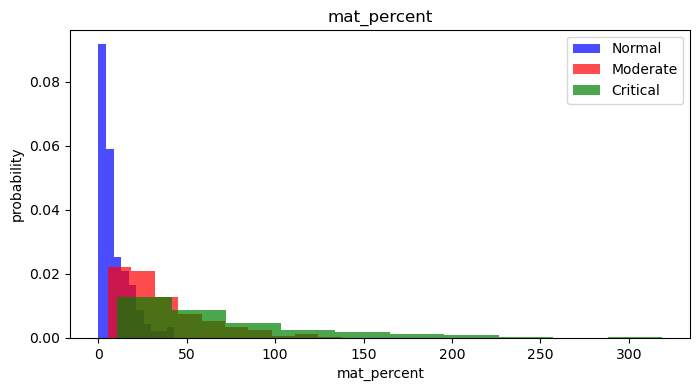

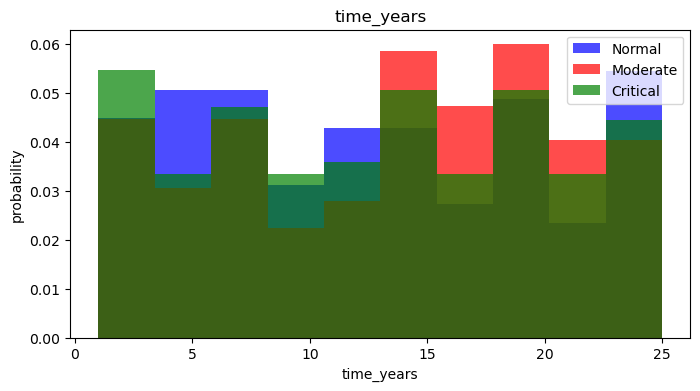

In [31]:
for label in columns[:-1]:
    plt.figure(figsize=(8, 4))  # create a fresh figure each iteration
    plt.hist(data[data['condition'] == 0][label], color='blue', label='Normal', alpha=0.7, density=True)
    plt.hist(data[data['condition'] == 1][label], color='red', label='Moderate', alpha=0.7, density=True)
    plt.hist(data[data['condition'] == 2][label], color='green', label='Critical', alpha=0.7, density=True)
    plt.title(label)
    plt.xlabel(label)
    plt.ylabel('probability')
    plt.legend()
    plt.savefig(f'{label}_plot.png', dpi=300, bbox_inches='tight')  # unique filename per label
    plt.show()
    plt.close()

In [14]:
train,valid,test = np.split(data.sample(frac = 1).reset_index(drop = True), [int( 0.6 *len(data)),int(0.8 * len(data))])

C:\Users\Derah\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [15]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [16]:
def scaler (dataframe,oversample = False):
    x = dataframe[dataframe.columns[:-1]].values
    y = dataframe[dataframe.columns[-1]].values
    scaler = StandardScaler()
    x = scaler.fit_transform(x)

    if oversample:
        ros = RandomOverSampler()
        x,y = ros.fit_resample(x,y)

    data = np.hstack((x,np.reshape(y,(-1,1))))
    return data,x,y


In [17]:
train, x_train,y_train = scaler(train, oversample = True)
valid, x_validn,y_valid = scaler(valid, oversample = False)
test, x_test,y_test = scaler(test, oversample = False)

## K - Nearest Classification

In [18]:
from sklearn.neighbors import KNeighborsClassifier

In [19]:
knn = KNeighborsClassifier(n_neighbors=5)

In [20]:
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [21]:
y_pred = knn.predict(x_test)

In [22]:
from sklearn.metrics import classification_report

In [23]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.84      0.78        45
           1       0.55      0.69      0.61        49
           2       0.99      0.80      0.89       106

    accuracy                           0.79       200
   macro avg       0.76      0.78      0.76       200
weighted avg       0.82      0.79      0.80       200



## SVM Classification

In [24]:
from sklearn.svm import SVC

In [25]:
svm = SVC()

In [26]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [27]:
y_pred = svm.predict(x_test)

In [28]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94        45
           1       0.73      0.98      0.83        49
           2       1.00      0.87      0.93       106

    accuracy                           0.91       200
   macro avg       0.90      0.92      0.90       200
weighted avg       0.93      0.91      0.91       200

